In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
import h5py
sys.path.append('../')
import analysis_utils as utils
utils.load_plotting_setting()

from astropy.time import Time, TimeDelta
from astropy.coordinates import EarthLocation

In [30]:
datasets_0 = ['20250104_4e-8mbar_alignment0_long',
            '20250105_2e-8mbar_alignment0_long',
            '20250106_2e-8mbar_8e_alignment0_long',
            '20250107_1e-8mbar_8e_alignment0_long',
            '20250108_1e-8mbar_8e_alignment0_long',
            '20250109_1e-8mbar_8e_alignment1_long',
            '20250110_1e-8mbar_8e_alignment1_long',
            '20250111_1e-8mbar_8e_alignment1_long',
            '20250112_9e-9mbar_8e_alignment1_long',
            '20250113_5e-8mbar_8e_alignment1_long',
            '20250114_1e-8mbar_1e_alignment1_long',
            '20250115_8e-9mbar_0e_alignment1_long',
            '20250116_8e-9mbar_0e_alignment1_long_wrong_lo',
            '20250117_8e-9mbar_0e_alignment1_long',
            '20250118_8e-9mbar_1e_alignment1_long',
            '20250120_8e-9mbar_1e_alignment1_long_wbackscat',
            '20250121_8e-9mbar_1e_alignment1_long',
            '20250122_8e-9mbar_1e_alignment1_long',
            '20250123_7e-9mbar_1e_alignment1_long',
            '20250124_7e-9mbar_1e_alignment1_long',
            '20250125_7e-9mbar_1e_alignment1_long'    
        ]
datasets_1 = ['20241222_5e-8mbar_10e_alignment0_long']
datasets_2 = ['20241227_6e-8mbar_alignment0_long']

In [42]:
def read_summed_hists(datasets):
    time_per_search = 50e-6 # s
    out_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/for_background'

    bc = None
    hists, livetimes = [], []
    for dataset in datasets:
        outfile_name = f'{dataset}_summed_histograms.hdf5'
        _file = h5py.File(os.path.join(out_dir, outfile_name), 'r')
        
        if bc is None:
            bc = _file['summed_histograms'].attrs['bc']
        hh_det_noise = _file['summed_histograms']['hh_det_noise_sum'][:]
        hh_det_noise_chi2 = _file['summed_histograms']['hh_det_noise_chi2_sum'][:]

        hists.append(hh_det_noise_chi2)
        livetimes.append(np.sum(hh_det_noise) * time_per_search)

        _file.close()
        
    return bc, livetimes, hists

In [43]:
bc_0, livetimes_0, hists_20250103 = read_summed_hists(datasets_0)
bc_1, livetimes_1, hists_20241221 = read_summed_hists(datasets_1)
bc_2, livetiems_2, hists_20241226 = read_summed_hists(datasets_2)


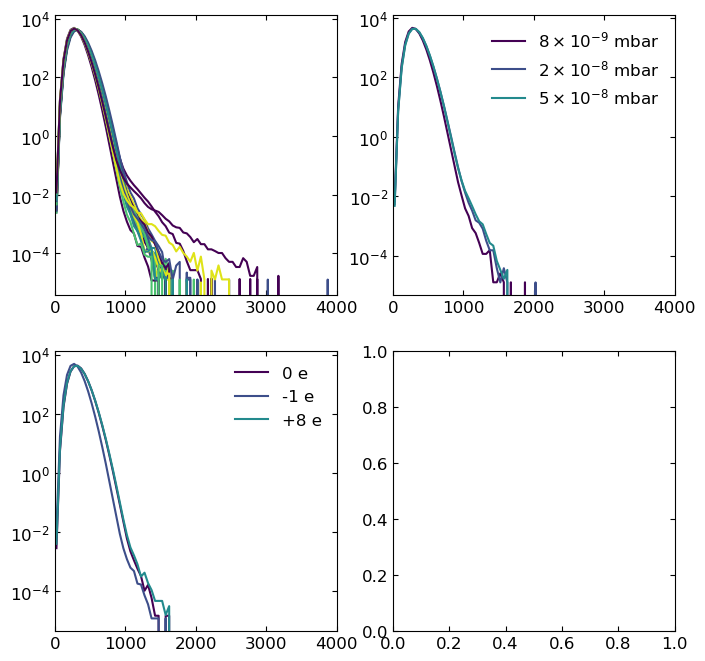

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

ax0 = axes[0, 0]
for i in range(len(hists_20250103)):
    ax0.plot(bc_0, hists_20250103[i]/livetimes_0[i])

ax1 = axes[0, 1]
idx_plot = [17, 2, 9]
labels_pressure = ['$8 \\times 10^{{-9}}$ mbar', '$2 \\times 10^{{-8}}$ mbar', '$5 \\times 10^{{-8}}$ mbar']
for i, idx in enumerate(idx_plot):
    ax1.plot(bc_0, hists_20250103[idx]/livetimes_0[idx], label=labels_pressure[i])

ax2 = axes[1, 0]
idx_plot = [11, 15, 7]
labels_charge = [r'0 e', r'-1 e', r'+8 e']
for i, idx in enumerate(idx_plot):
    ax2.plot(bc_0, hists_20250103[idx]/livetimes_0[idx], label=labels_charge[i])

ax2 = axes[1, 0]
idx_plot = [11, 15, 7]
labels_charge = [r'0 e', r'-1 e', r'+8 e']
for i, idx in enumerate(idx_plot):
    ax2.plot(bc_0, hists_20250103[idx]/livetimes_0[idx], label=labels_charge[i])


for a in [ax0, ax1, ax2]:
    a.set_yscale('log')
    a.set_xlim(0, 4000)

for a in [ax1, ax2]:
    a.legend(frameon=False)

## Daily modulation

In [2]:
latitude_newhaven  = 41.31 # deg
longitude_newhaven = -72.923611 # deg
elevation_newhaven = 18 # m

amp2kev_sphere_20241202 = 5945.245097647231
amp2kev_sphere_20250103 = 5923.2059527417405

In [3]:
file0 = h5py.File(rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/sphere_20241202_unbinned_amps.h5py')
file1 = h5py.File(rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/sphere_20250103_unbinned_amps.h5py')

amps0 = file0['unbinned_amps']['amplitude'][:]
amps1 = file1['unbinned_amps']['amplitude'][:]
time0 = file0['unbinned_amps']['time'][:]
time1 = file1['unbinned_amps']['time'][:]

file0.close()
file1.close()

Text(0, 0.5, 'Counts')

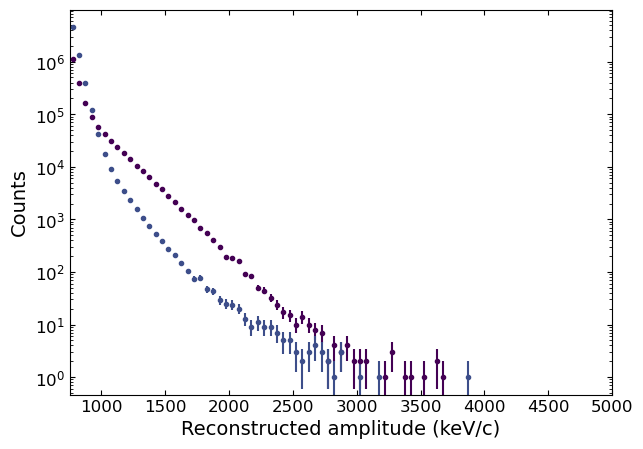

In [12]:
bins = np.arange(0, 10000, 50)  # keV
bc = 0.5 * (bins[:-1] + bins[1:])

amps_kev_0 = np.abs(amps0 * amp2kev_sphere_20241202)
amps_kev_1 = np.abs(amps1 * amp2kev_sphere_20250103)

hist0, be0 = np.histogram(amps_kev_0, bins)
hist1, be1 = np.histogram(amps_kev_1, bins)

plt.errorbar(bc, hist0, yerr=np.sqrt(hist0) ,fmt='.')
plt.errorbar(bc, hist1, yerr=np.sqrt(hist1), fmt='.')

plt.xlim(750, 5000)
plt.yscale('log')

plt.xlabel('Reconstructed amplitude (keV/c)')
plt.ylabel('Counts')

In [6]:
location = EarthLocation(lat=latitude_newhaven, lon=longitude_newhaven, height=elevation_newhaven)
thr_kev = 1250

t0 = Time(time0[amps_kev_0 > thr_kev], format='unix', scale='utc')
t1 = Time(time1[amps_kev_1 > thr_kev], format='unix', scale='utc')

# Calculate the sidereal time
lst0 = t0.sidereal_time('apparent', longitude=location.lon)
lst1 = t1.sidereal_time('apparent', longitude=location.lon)

In [7]:
def get_local_hour(utc_offset, t_utc):
    t_locals = t_utc + TimeDelta(utc_offset * 3600, format='sec')

    t_local_hours = np.empty(t_locals.size)
    for i, t_local in enumerate(t_locals):
        t_local_hours[i] = t_local.datetime.hour + t_local.datetime.minute/60 + t_local.datetime.second/3600

    return t_local_hours


In [8]:
# Calculate the local time (UTC-5) during data taking
utc_offset = -5

t0_local_hours = get_local_hour(utc_offset, t0)
t1_local_hours = get_local_hour(utc_offset, t1)

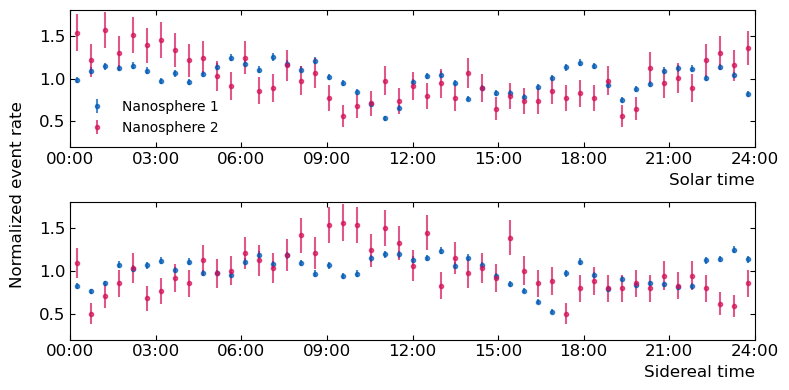

In [12]:
bins = np.linspace(0, 24, 50)
bc = 0.5 * (bins[1:] + bins[:-1])

hist0_local, be0 = np.histogram(t0_local_hours, bins=bins)
hist1_local, be1 = np.histogram(t1_local_hours, bins=bins)

hist0, be0 = np.histogram(lst0.hour, bins=bins)
hist1, be1 = np.histogram(lst1.hour, bins=bins)

fig, axes = plt.subplots(2, 1, figsize=(8, 4))

axes[0].errorbar(bc, hist0_local/np.mean(hist0_local), yerr=np.sqrt(hist0_local)/np.mean(hist0_local), fmt='.', color='#005AB5', alpha=0.7, label='Nanosphere 1')
axes[0].errorbar(bc, hist1_local/np.mean(hist1_local), yerr=np.sqrt(hist1_local)/np.mean(hist1_local), fmt='.', color='#D41159', alpha=0.7, label='Nanosphere 2')

axes[1].errorbar(bc, hist0/np.mean(hist0), yerr=np.sqrt(hist0)/np.mean(hist0), fmt='.', color='#005AB5', alpha=0.7)
axes[1].errorbar(bc, hist1/np.mean(hist1), yerr=np.sqrt(hist1)/np.mean(hist1), fmt='.', color='#D41159', alpha=0.7)

axes[0].legend(frameon=False, fontsize=10)
fig.supylabel('Normalized event rate', fontsize=12)
axes[0].set_xlabel('Solar time', ha='right', x=1.0, fontsize=12)
axes[1].set_xlabel('Sidereal time', ha='right', x=1.0, fontsize=12)

def float_to_time(x, pos):
    hour = int(x)
    minute = int((x - hour) * 60)
    return f"{hour:02d}:{minute:02d}"

for ax in axes:
    ax.set_xlim(0, 24)
    ax.set_ylim(0.2, 1.8)

    ax.set_xticks(np.arange(0, 27, 3))  # every hour
    ax.xaxis.set_major_formatter(plt.FuncFormatter(float_to_time))

fig.tight_layout()
fig.align_labels()

plt.savefig('../paper_plots/daily_modulation.pdf', dpi=600)